<a href="https://colab.research.google.com/github/mannatkalani/mailguard-ai/blob/main/spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("spam_dataset.csv")
df

,label,text,source
0,ham,conf . call details here are the details for t...,enron_email
1,ham,"hpl nom for june 27 , 2000 ( see attached file...",enron_email
2,spam,FREE GAME. Get Rayman Golf 4 FREE from the O2 ...,sms
3,spam,re [ 1 ] : real fuckers order 3793 - ohin cial...,enron_email
4,ham,competitive analysis report - us terrorism att...,enron_email
...,...,...,...
35626,ham,special assets status attached is the june 8 n...,enron_email
35627,ham,sitara availability as a precautionary measure...,enron_email
35628,ham,"names bryan ,\nthe person from citibank :\nall...",enron_email
35629,spam,U have a Secret Admirer who is looking 2 make ...,sms


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35631 entries, 0 to 35630
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   35631 non-null  object
 1   text    35631 non-null  object
 2   source  35631 non-null  object
dtypes: object(3)
memory usage: 835.2+ KB


In [ ]:
df.describe

<bound method NDFrame.describe of       label                                               text       source
0       ham  conf . call details here are the details for t...  enron_email
1       ham  hpl nom for june 27 , 2000 ( see attached file...  enron_email
2      spam  FREE GAME. Get Rayman Golf 4 FREE from the O2 ...          sms
3      spam  re [ 1 ] : real fuckers order 3793 - ohin cial...  enron_email
4       ham  competitive analysis report - us terrorism att...  enron_email
...     ...                                                ...          ...
35626   ham  special assets status attached is the june 8 n...  enron_email
35627   ham  sitara availability as a precautionary measure...  enron_email
35628   ham  names bryan ,\nthe person from citibank :\nall...  enron_email
35629  spam  U have a Secret Admirer who is looking 2 make ...          sms
35630  spam  mail delivery failed : returning message to se...  enron_email

[35631 rows x 3 columns]>

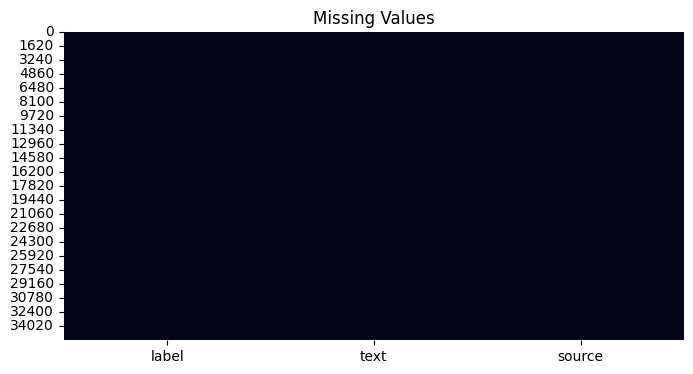

In [ ]:
df.isnull().sum()

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Duplicate text messages:", df['text'].duplicated().sum())

Duplicate text messages: 0


In [ ]:
df['label'].value_counts()

,count
label,
ham,20426
spam,15205


In [ ]:
label_percentage = df['label'].value_counts(normalize=True) * 100
print(label_percentage)

label
ham     57.326485
spam    42.673515
Name: proportion, dtype: float64


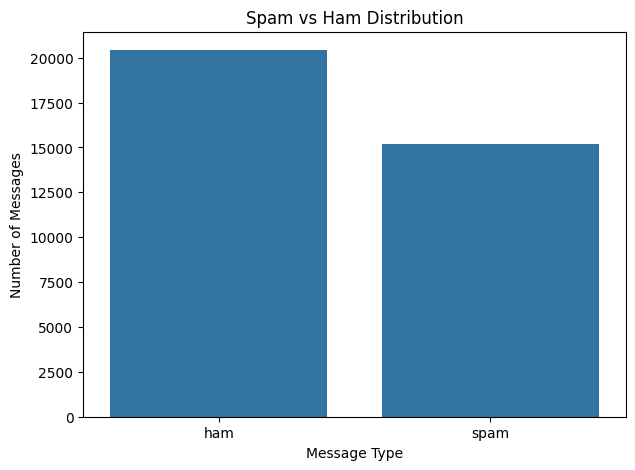

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='label')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
df['source'].value_counts()

,count
source,
enron_email,30462
sms,5169


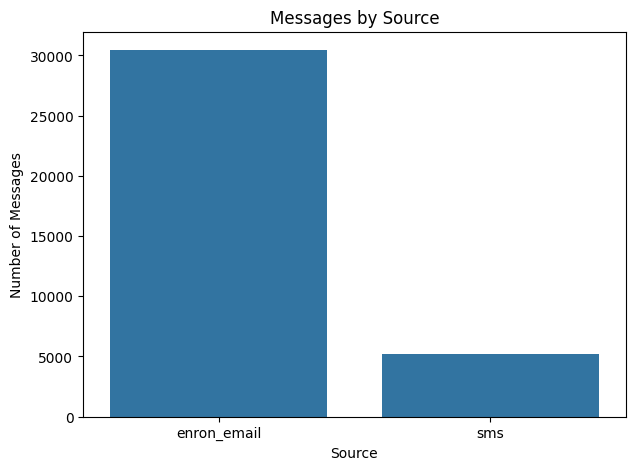

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='source')
plt.title("Messages by Source")
plt.xlabel("Source")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
pd.crosstab(df['source'], df['label'])

label,ham,spam
source,,
enron_email,15910,14552
sms,4516,653


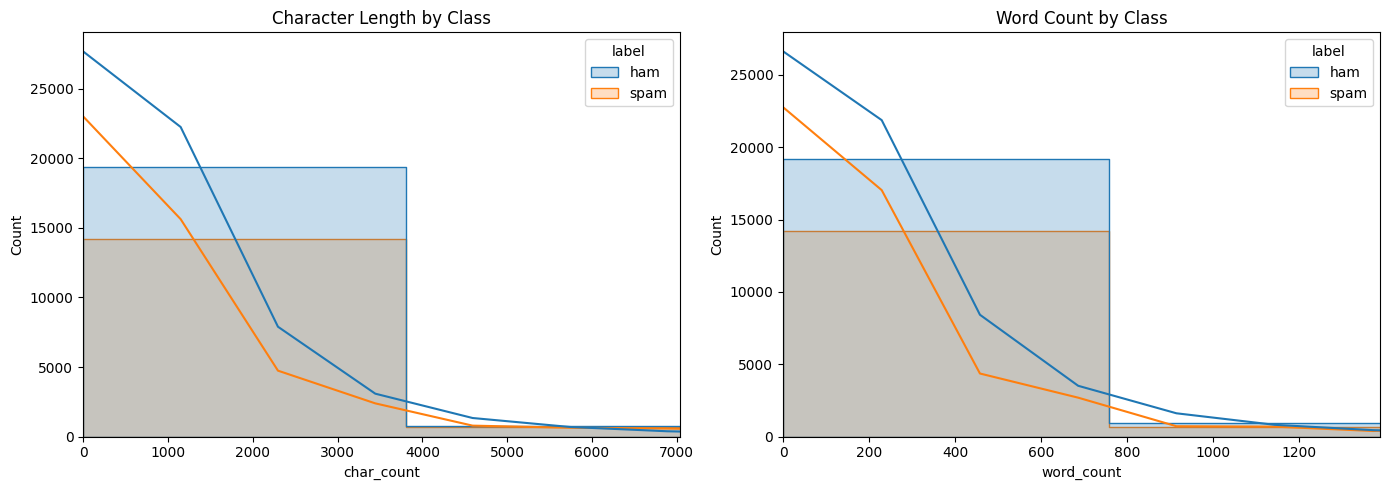

In [ ]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)
df['avg_word_len'] = df['char_count'] / df['word_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='char_count', hue='label', bins=60, kde=True,
             element='step', common_norm=False, ax=axes[0])
axes[0].set_xlim(0, df['char_count'].quantile(0.98))
axes[0].set_title('Character Length by Class')

sns.histplot(data=df, x='word_count', hue='label', bins=60, kde=True,
             element='step', common_norm=False, ax=axes[1])
axes[1].set_xlim(0, df['word_count'].quantile(0.98))
axes[1].set_title('Word Count by Class')
plt.tight_layout()
plt.show()

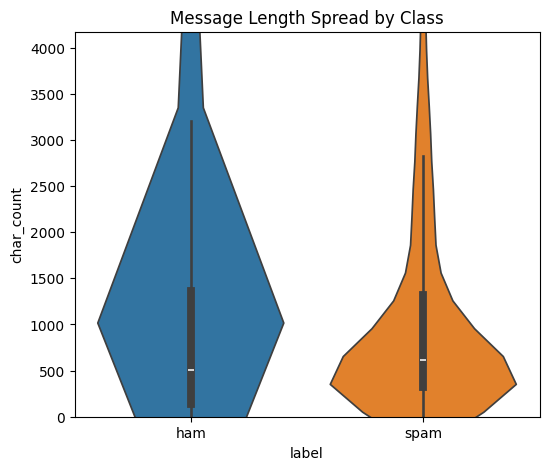

In [ ]:
plt.figure(figsize=(6,5))
sns.violinplot(x='label', y='char_count', data=df, hue='label', legend=False)
plt.ylim(0, df['char_count'].quantile(0.95))
plt.title("Message Length Spread by Class")
plt.show()

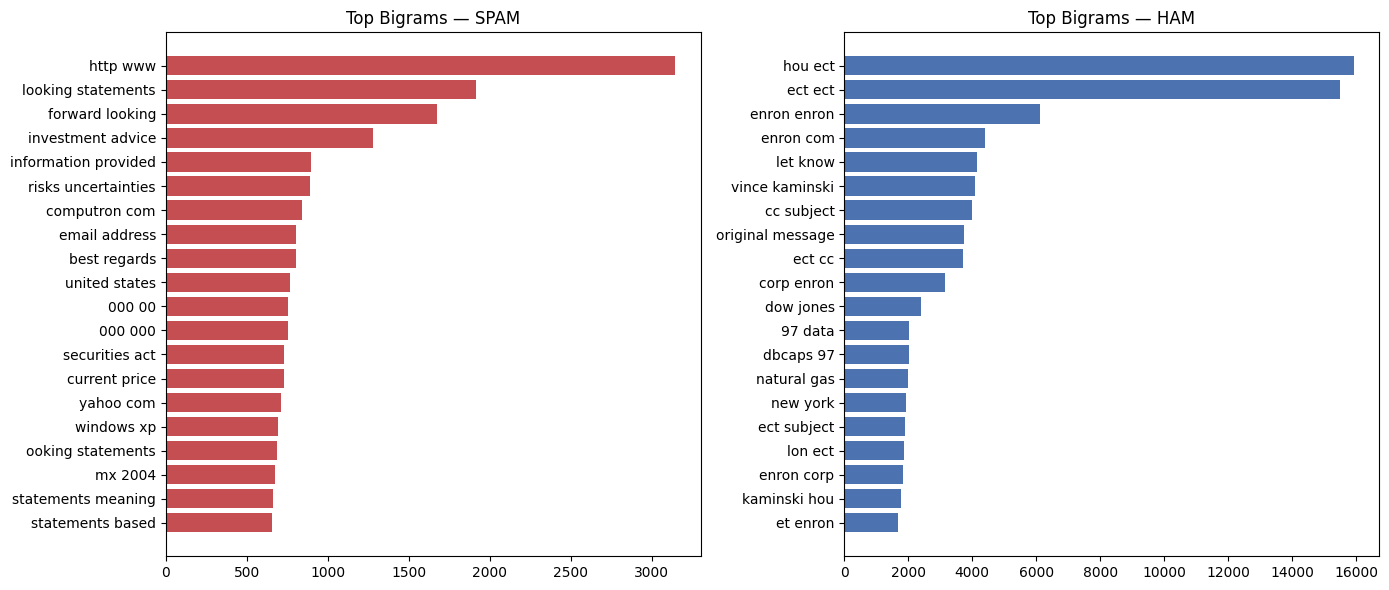

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, ngram_range=(1,1), n=20):
    cv = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=5000)
    X = cv.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = cv.get_feature_names_out()
    return sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:n]

spam_bigrams = top_ngrams(df[df.label=='spam']['text'], ngram_range=(2,2))
ham_bigrams  = top_ngrams(df[df.label=='ham']['text'], ngram_range=(2,2))

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, pairs, title, color in zip(axes, [spam_bigrams, ham_bigrams],
                                     ['Top Bigrams — SPAM','Top Bigrams — HAM'],
                                     ['#C44E52','#4C72B0']):
    words, freqs = zip(*pairs)
    ax.barh(words[::-1], freqs[::-1], color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()

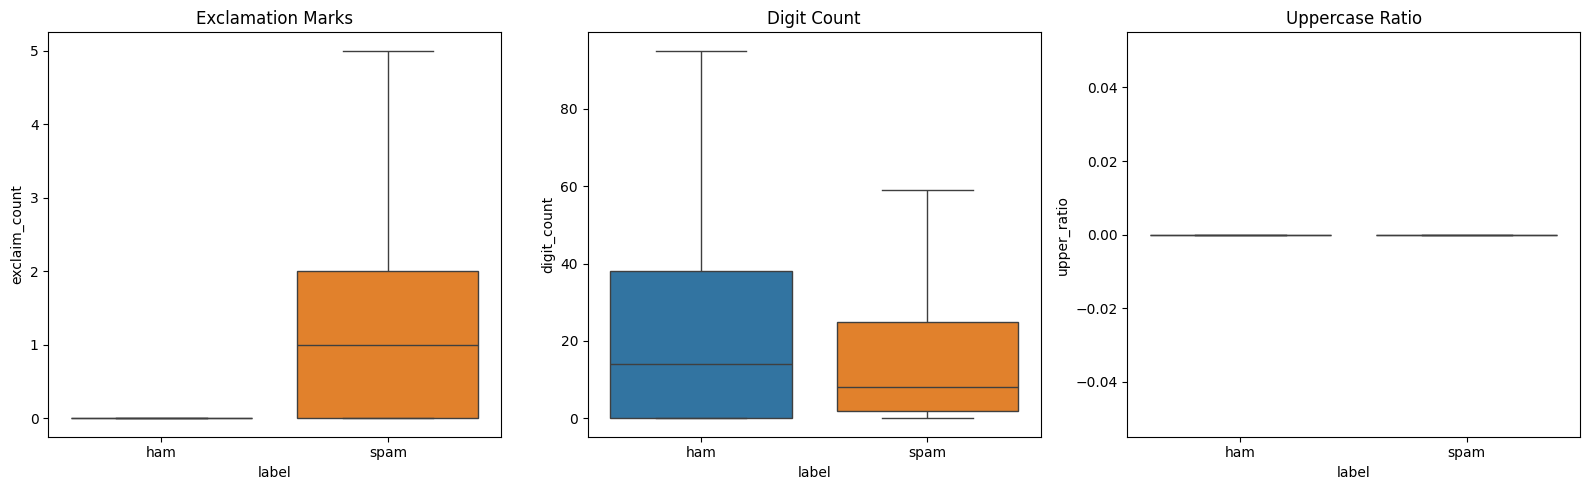

In [ ]:
df['exclaim_count'] = df['text'].str.count('!')
df['digit_count'] = df['text'].str.count(r'\d')
df['upper_ratio'] = df['text'].apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t),1))

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, col, title in zip(axes, ['exclaim_count','digit_count','upper_ratio'],
                           ['Exclamation Marks','Digit Count','Uppercase Ratio']):
    sns.boxplot(x='label', y=col, data=df, hue='label', showfliers=False,
                legend=False, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

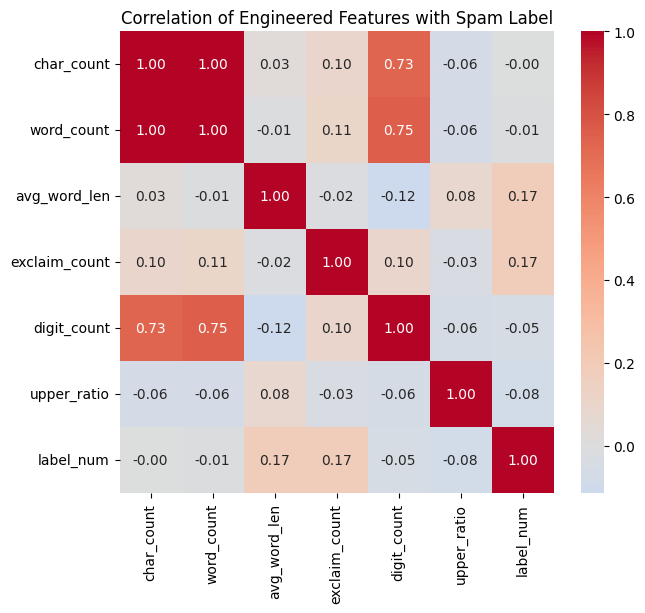

In [ ]:
df['label_num'] = (df['label']=='spam').astype(int)
corr = df[['char_count','word_count','avg_word_len','exclaim_count',
           'digit_count','upper_ratio','label_num']].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation of Engineered Features with Spam Label")
plt.show()

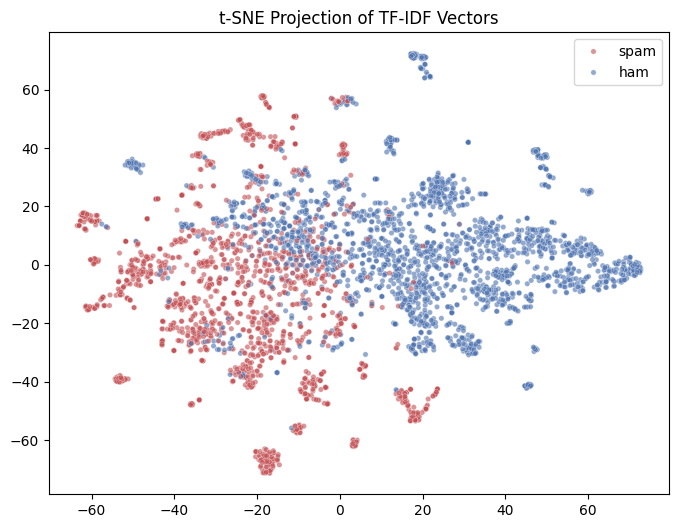

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['text'].sample(4000, random_state=42))
sample_labels = df['label'].sample(4000, random_state=42)

X_reduced = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_tfidf)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_reduced)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=sample_labels.values,
                 alpha=0.6, s=15, palette={'spam':'#C44E52','ham':'#4C72B0'})
plt.title("t-SNE Projection of TF-IDF Vectors")
plt.show()

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'\S+@\S+', ' email ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words and len(w) > 1]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df[['text','clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text,clean_text
0,conf . call details here are the details for t...,conf call detail detail conf call today num nu...
1,"hpl nom for june 27 , 2000 ( see attached file...",hpl nom june num num see attach file hplo num ...
2,FREE GAME. Get Rayman Golf 4 FREE from the O2 ...,free game get rayman golf num free num game ar...
3,re [ 1 ] : real fuckers order 3793 - ohin cial...,num real fucker order num ohin ciali soft tab ...
4,competitive analysis report - us terrorism att...,competit analysi report us terror attack enron...


In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

lr_cv = LogisticRegression(max_iter=1000)
lr_cv.fit(X_train_cv, y_train)

pred_cv = lr_cv.predict(X_test_cv)
print("CountVectorizer + LR Accuracy:", accuracy_score(y_test, pred_cv))
print(classification_report(y_test, pred_cv, target_names=['ham','spam']))

CountVectorizer + LR Accuracy: 0.9706748982741686
              precision    recall  f1-score   support

         ham       0.96      0.99      0.97      4086
        spam       0.98      0.95      0.97      3041

    accuracy                           0.97      7127
   macro avg       0.97      0.97      0.97      7127
weighted avg       0.97      0.97      0.97      7127



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = lr_tfidf.predict(X_test_tfidf)
print("TF-IDF + LR Accuracy:", accuracy_score(y_test, pred_tfidf))
print(classification_report(y_test, pred_tfidf, target_names=['ham','spam']))

TF-IDF + LR Accuracy: 0.9675880454609233
              precision    recall  f1-score   support

         ham       0.97      0.97      0.97      4086
        spam       0.96      0.96      0.96      3041

    accuracy                           0.97      7127
   macro avg       0.97      0.97      0.97      7127
weighted avg       0.97      0.97      0.97      7127



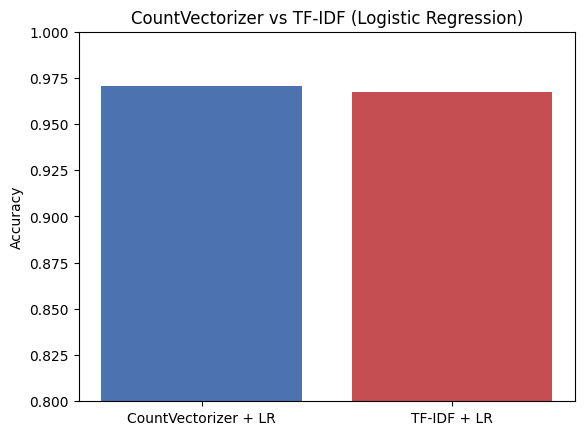

In [ ]:
import matplotlib.pyplot as plt

results = {'CountVectorizer + LR': accuracy_score(y_test, pred_cv),
           'TF-IDF + LR': accuracy_score(y_test, pred_tfidf)}

plt.bar(results.keys(), results.values(), color=['#4C72B0','#C44E52'])
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("CountVectorizer vs TF-IDF (Logistic Regression)")
plt.show()

In [ ]:
def predict_message(text, vectorizer, model):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "SPAM" if pred == 1 else "HAM"

print(predict_message("Congratulations! You won a free iPhone, click now!", tfidf, lr_tfidf))
print(predict_message("Hey, are we still meeting for lunch tomorrow?", tfidf, lr_tfidf))

SPAM
HAM


In [ ]:
from sklearn.model_selection import cross_val_score

# CountVectorizer + LR
cv_scores_count = cross_val_score(lr_cv, X_train_cv, y_train, cv=5, scoring='accuracy')
print("CountVectorizer + LR — Cross-Val Scores:", cv_scores_count)
print("Average CV Accuracy:", cv_scores_count.mean())

# TF-IDF + LR
cv_scores_tfidf = cross_val_score(lr_tfidf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
print("\nTF-IDF + LR — Cross-Val Scores:", cv_scores_tfidf)
print("Average CV Accuracy:", cv_scores_tfidf.mean())

CountVectorizer + LR — Cross-Val Scores: [0.96614629 0.97000526 0.97105771 0.96895282 0.96719298]
Average CV Accuracy: 0.9686710118569535

TF-IDF + LR — Cross-Val Scores: [0.96684792 0.96877741 0.97018067 0.96439221 0.96438596]
Average CV Accuracy: 0.9669168351504969


In [ ]:
from sklearn.metrics import accuracy_score

acc_count = accuracy_score(y_test, pred_cv)
acc_tfidf = accuracy_score(y_test, pred_tfidf)

print("CountVectorizer + LR Test Accuracy:", acc_count)
print("TF-IDF + LR Test Accuracy:", acc_tfidf)

CountVectorizer + LR Test Accuracy: 0.9706748982741686
TF-IDF + LR Test Accuracy: 0.9675880454609233


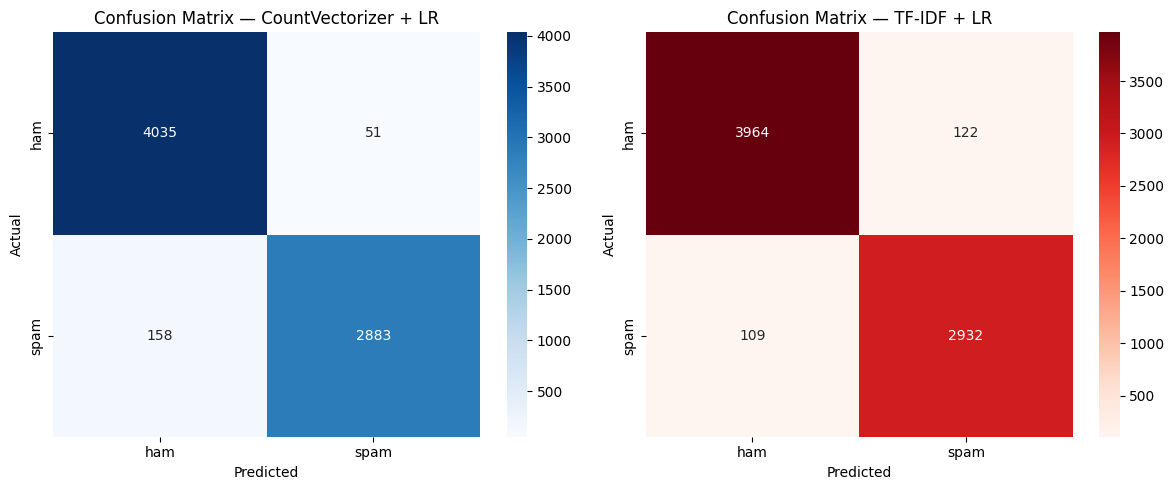

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_count = confusion_matrix(y_test, pred_cv)
cm_tfidf = confusion_matrix(y_test, pred_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_count, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=axes[0])
axes[0].set_title("Confusion Matrix — CountVectorizer + LR")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=axes[1])
axes[1].set_title("Confusion Matrix — TF-IDF + LR")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("=== CountVectorizer + LR ===")
print(classification_report(y_test, pred_cv, target_names=['ham','spam']))

print("=== TF-IDF + LR ===")
print(classification_report(y_test, pred_tfidf, target_names=['ham','spam']))

=== CountVectorizer + LR ===
              precision    recall  f1-score   support

         ham       0.96      0.99      0.97      4086
        spam       0.98      0.95      0.97      3041

    accuracy                           0.97      7127
   macro avg       0.97      0.97      0.97      7127
weighted avg       0.97      0.97      0.97      7127

=== TF-IDF + LR ===
              precision    recall  f1-score   support

         ham       0.97      0.97      0.97      4086
        spam       0.96      0.96      0.96      3041

    accuracy                           0.97      7127
   macro avg       0.97      0.97      0.97      7127
weighted avg       0.97      0.97      0.97      7127



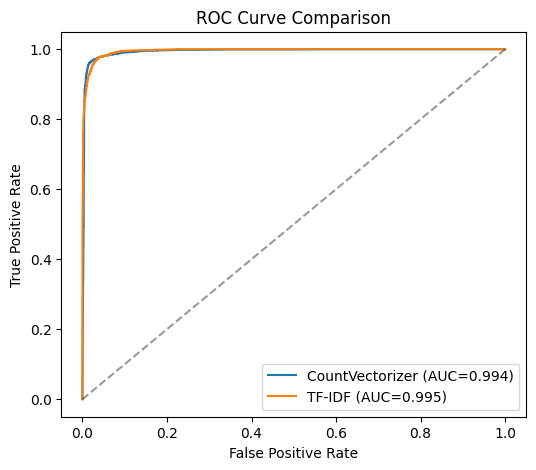

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

probs_count = lr_cv.predict_proba(X_test_cv)[:,1]
probs_tfidf = lr_tfidf.predict_proba(X_test_tfidf)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, probs_count)
fpr2, tpr2, _ = roc_curve(y_test, probs_tfidf)

plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label=f"CountVectorizer (AUC={roc_auc_score(y_test, probs_count):.3f})")
plt.plot(fpr2, tpr2, label=f"TF-IDF (AUC={roc_auc_score(y_test, probs_tfidf):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_cv = MultinomialNB()
nb_cv.fit(X_train_cv, y_train)

pred_nb_cv = nb_cv.predict(X_test_cv)
print("CountVectorizer + Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb_cv))
print(classification_report(y_test, pred_nb_cv, target_names=['ham','spam']))

CountVectorizer + Naive Bayes Accuracy: 0.9371404518030026
              precision    recall  f1-score   support

         ham       0.98      0.91      0.94      4086
        spam       0.89      0.98      0.93      3041

    accuracy                           0.94      7127
   macro avg       0.93      0.94      0.94      7127
weighted avg       0.94      0.94      0.94      7127



In [ ]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
print("TF-IDF + Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb_tfidf))
print(classification_report(y_test, pred_nb_tfidf, target_names=['ham','spam']))

TF-IDF + Naive Bayes Accuracy: 0.9607127823768766
              precision    recall  f1-score   support

         ham       0.96      0.97      0.97      4086
        spam       0.96      0.95      0.95      3041

    accuracy                           0.96      7127
   macro avg       0.96      0.96      0.96      7127
weighted avg       0.96      0.96      0.96      7127



In [ ]:
cv_scores_nb_count = cross_val_score(nb_cv, X_train_cv, y_train, cv=5, scoring='accuracy')
cv_scores_nb_tfidf = cross_val_score(nb_tfidf, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print("NB + CountVectorizer — CV Accuracy:", cv_scores_nb_count.mean())
print("NB + TF-IDF — CV Accuracy:", cv_scores_nb_tfidf.mean())

NB + CountVectorizer — CV Accuracy: 0.9338688441855384
NB + TF-IDF — CV Accuracy: 0.9570936216176295


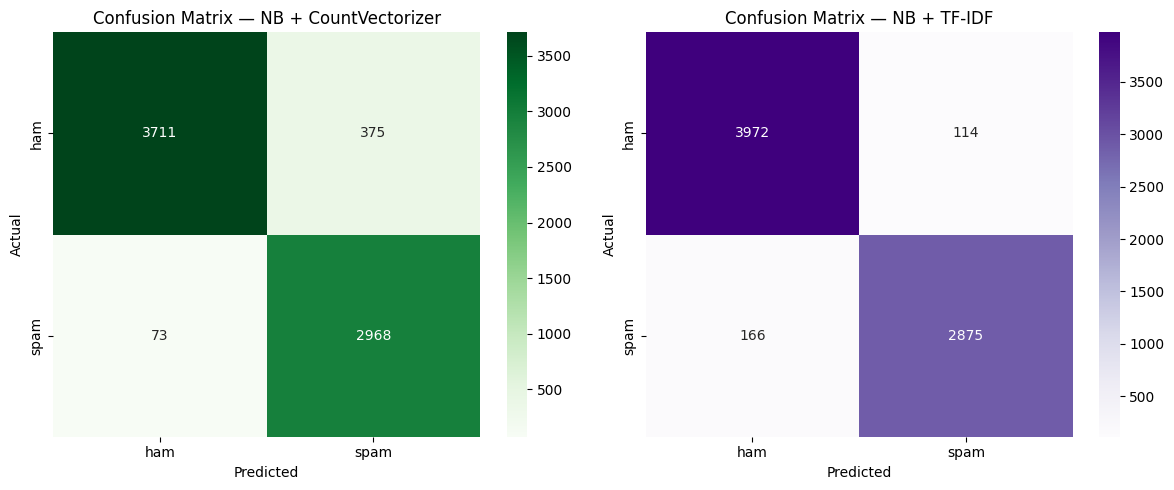

In [ ]:
cm_nb_count = confusion_matrix(y_test, pred_nb_cv)
cm_nb_tfidf = confusion_matrix(y_test, pred_nb_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_nb_count, annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=axes[0])
axes[0].set_title("Confusion Matrix — NB + CountVectorizer")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_nb_tfidf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=axes[1])
axes[1].set_title("Confusion Matrix — NB + TF-IDF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

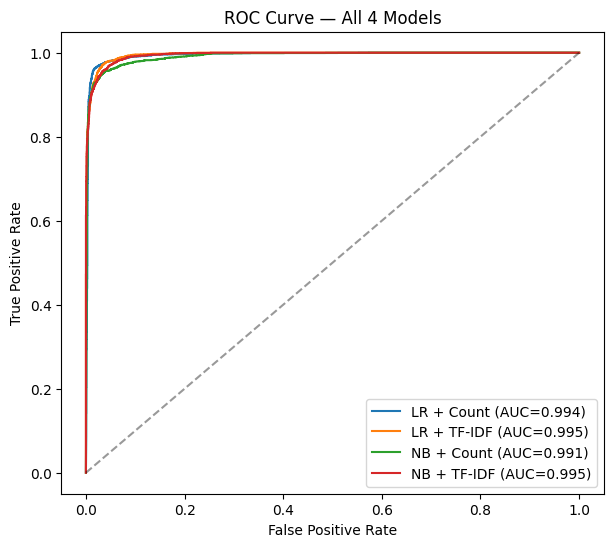

In [ ]:
probs_nb_count = nb_cv.predict_proba(X_test_cv)[:,1]
probs_nb_tfidf = nb_tfidf.predict_proba(X_test_tfidf)[:,1]

fpr3, tpr3, _ = roc_curve(y_test, probs_nb_count)
fpr4, tpr4, _ = roc_curve(y_test, probs_nb_tfidf)

plt.figure(figsize=(7,6))
plt.plot(fpr1, tpr1, label=f"LR + Count (AUC={roc_auc_score(y_test, probs_count):.3f})")
plt.plot(fpr2, tpr2, label=f"LR + TF-IDF (AUC={roc_auc_score(y_test, probs_tfidf):.3f})")
plt.plot(fpr3, tpr3, label=f"NB + Count (AUC={roc_auc_score(y_test, probs_nb_count):.3f})")
plt.plot(fpr4, tpr4, label=f"NB + TF-IDF (AUC={roc_auc_score(y_test, probs_nb_tfidf):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All 4 Models")
plt.legend()
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Model': ['LR + Count', 'LR + TF-IDF', 'NB + Count', 'NB + TF-IDF'],
    'CV Accuracy (avg)': [cv_scores_count.mean(), cv_scores_tfidf.mean(),
                           cv_scores_nb_count.mean(), cv_scores_nb_tfidf.mean()],
    'Test Accuracy': [acc_count, acc_tfidf,
                       accuracy_score(y_test, pred_nb_cv), accuracy_score(y_test, pred_nb_tfidf)],
    'AUC': [roc_auc_score(y_test, probs_count), roc_auc_score(y_test, probs_tfidf),
            roc_auc_score(y_test, probs_nb_count), roc_auc_score(y_test, probs_nb_tfidf)]
})
summary.sort_values('Test Accuracy', ascending=False)

,Model,CV Accuracy (avg),Test Accuracy,AUC
0,LR + Count,0.968671,0.970675,0.994096
1,LR + TF-IDF,0.966917,0.967588,0.995471
3,NB + TF-IDF,0.957094,0.960713,0.994642
2,NB + Count,0.933869,0.937140,0.991472


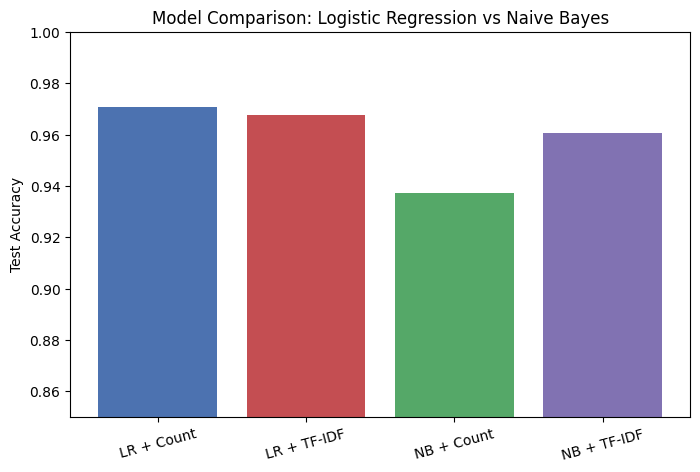

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(summary['Model'], summary['Test Accuracy'], color=['#4C72B0','#C44E52','#55A868','#8172B2'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison: Logistic Regression vs Naive Bayes")
plt.xticks(rotation=15)
plt.show()

In [ ]:
def predict_all_models(text):
    cleaned = clean_text(text)
    vec_count = cv.transform([cleaned])
    vec_tfidf = tfidf.transform([cleaned])
    results = {
        'LR + Count': lr_cv.predict(vec_count)[0],
        'LR + TF-IDF': lr_tfidf.predict(vec_tfidf)[0],
        'NB + Count': nb_cv.predict(vec_count)[0],
        'NB + TF-IDF': nb_tfidf.predict(vec_tfidf)[0],
    }
    return {k: ("SPAM" if v==1 else "HAM") for k,v in results.items()}

predict_all_models("Congratulations! You won a free iPhone, click now!")

{'LR + Count': 'HAM',
 'LR + TF-IDF': 'SPAM',
 'NB + Count': 'SPAM',
 'NB + TF-IDF': 'HAM'}